#**1. 그래프의 상태 업데이트**
- HumanMessage : 사용자(사람)의 메시지
- AIMessage : AI(LLM)의 메시지
- AnyMessage : HumanMessage, AIMessage를 포함하는 메시지

In [25]:
!pip install langgraph

In [26]:
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict

class State(TypedDict):
    messages: list[AnyMessage]
    extra_field: int

In [27]:
from langchain_core.messages import AIMessage

def node(state: State):
    messages = state["messages"]
    new_message = AIMessage("안녕하세요! 무엇을 도와드릴까요?")

    # return {"messages": new_message, "extra_field": 10}
    return {"messages": messages + [new_message], "extra_field": 10}

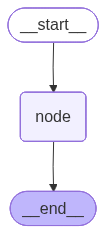

In [28]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(State)
graph_builder.add_node("node", node)
# set_entry_point : 그래프의 시작 노드를 지정하는 엣지 (START -> "node")
graph_builder.set_entry_point("node")
graph = graph_builder.compile()

graph

In [29]:
from langchain_core.messages import HumanMessage

result = graph.invoke({"messages": [HumanMessage("안녕")]})
result

{'messages': [HumanMessage(content='안녕', additional_kwargs={}, response_metadata={}),
  AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'extra_field': 10}

In [30]:
result["messages"]

[HumanMessage(content='안녕', additional_kwargs={}, response_metadata={}),
 AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

#**2. 대화메시지 상태 누적 업데이트**
[add_messages](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.message.add_messages) 는 기존 메시지에서 추가 메시지를 병합하는 데 사용하는 함수로, 새로 들어온 메시지를 추가할 때 사용할 수 있는 리듀서 역할

In [31]:
from typing_extensions import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    extra_field: int

In [32]:
def node(state: State):
    messages = state["messages"]
    new_message = AIMessage("안녕하세요! 무엇을 도와드릴까요?")

    return {"messages": new_message, "extra_field": 10}

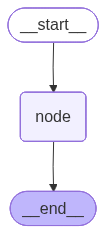

In [33]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(State)
graph_builder.add_node("node", node)
graph_builder.set_entry_point("node")
graph = graph_builder.compile()

graph

In [34]:
input_message = {"role": "user", "content": "안녕하세요."}

result = graph.invoke({"messages": [input_message]})

for message in result["messages"]:
# pretty_print()는 데이터나 객체를 보기 좋게(Pretty) 정리해서 출력하는 함수
    message.pretty_print()

================================ Human Message =================================

안녕하세요.
================================== Ai Message ==================================

안녕하세요! 무엇을 도와드릴까요?


In [35]:
result["messages"]

[HumanMessage(content='안녕하세요.', additional_kwargs={}, response_metadata={}, id='939573a9-199b-4ceb-b75e-68e171d4c77e'),
 AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, id='a0972a2f-c52a-4d69-a0dc-bd51b5e76e06', tool_calls=[], invalid_tool_calls=[])]

invoke : 하나의 요청에 대한 결과를 받을 때 까지 코드 실행 멈춤. 한번에 하나의 요청을 처리함

In [36]:
graph.invoke({"messages": [input_message]})

{'messages': [HumanMessage(content='안녕하세요.', additional_kwargs={}, response_metadata={}, id='8c8e7385-e2fc-4932-944c-fa0ca4c07028'),
  AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, id='065d9169-9ef0-4f54-ac21-af5945a9817b', tool_calls=[], invalid_tool_calls=[])],
 'extra_field': 10}

ainvoke : 비동기 처리로 여러 요청을 동시에 보낼 수 있음

In [37]:
await graph.ainvoke({"messages": [input_message]})

{'messages': [HumanMessage(content='안녕하세요.', additional_kwargs={}, response_metadata={}, id='b47f10cc-138d-4b9c-ad5c-82b9d1948464'),
  AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, id='f6a46853-a816-45e9-84c9-1cd7ee245e68', tool_calls=[], invalid_tool_calls=[])],
 'extra_field': 10}

stream : 중간 결과를 실시간으로 반환함

- stream_mode="values" 각 단계의 현재 상태 값 출력
- Default) stream_mode="updates" 각 단계의 상태 업데이트만 출력
- stream_mode="messages" 각 단계의 메시지 출력

In [46]:
for chunk in graph.stream({"messages": [input_message]}, stream_mode="values"):
    print(chunk)
    for state_key, state_value in chunk.items():
        if state_key == "messages":
            state_value[-1].pretty_print()
    print('-'*100)

{'messages': [HumanMessage(content='안녕하세요.', additional_kwargs={}, response_metadata={}, id='c65bb328-2e23-4b37-a91f-ba8fcb544fb0')]}
================================ Human Message =================================

안녕하세요.
----------------------------------------------------------------------------------------------------
{'messages': [HumanMessage(content='안녕하세요.', additional_kwargs={}, response_metadata={}, id='c65bb328-2e23-4b37-a91f-ba8fcb544fb0'), AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, id='fde2f01a-9890-484a-8566-bc3f7dc9a079', tool_calls=[], invalid_tool_calls=[])], 'extra_field': 10}
================================== Ai Message ==================================

안녕하세요! 무엇을 도와드릴까요?
----------------------------------------------------------------------------------------------------


In [47]:
for chunk in graph.stream({"messages": [input_message]}, stream_mode="updates"):
    print(chunk)
    for node, value in chunk.items():
        if node:
            print(node)
        if "messages" in value:
            print(value['messages'].content)

{'node': {'messages': AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, id='f8a56408-093c-4a32-85e1-8911fe5a485c', tool_calls=[], invalid_tool_calls=[]), 'extra_field': 10}}
node
안녕하세요! 무엇을 도와드릴까요?


In [48]:
for chunk_msg, metadata in graph.stream({"messages": [input_message]}, stream_mode="messages"):
    print(chunk_msg)
    print(chunk_msg.content)
    print(metadata)
    print(metadata["langgraph_node"])

content='안녕하세요! 무엇을 도와드릴까요?' additional_kwargs={} response_metadata={} id='1c8b246f-de34-435e-ab05-8502bcce28ae' tool_calls=[] invalid_tool_calls=[]
안녕하세요! 무엇을 도와드릴까요?
{'langgraph_step': 1, 'langgraph_node': 'node', 'langgraph_triggers': ('branch:to:node',), 'langgraph_path': ('__pregel_pull', 'node'), 'langgraph_checkpoint_ns': 'node:e6e4dabd-08d1-fddb-0357-833f7c20199e'}
node


astream : 비동기 방식으로 스트리밍 처리

In [49]:
async for chunk_msg, metadata in graph.astream({"messages": [input_message]}, stream_mode="messages"):
    print(chunk_msg)
    print(chunk_msg.content)
    print(metadata)
    print(metadata["langgraph_node"])

content='안녕하세요! 무엇을 도와드릴까요?' additional_kwargs={} response_metadata={} id='ce2492f4-224b-4384-890a-1c851990294f' tool_calls=[] invalid_tool_calls=[]
안녕하세요! 무엇을 도와드릴까요?
{'langgraph_step': 1, 'langgraph_node': 'node', 'langgraph_triggers': ('branch:to:node',), 'langgraph_path': ('__pregel_pull', 'node'), 'langgraph_checkpoint_ns': 'node:92c5e09b-b09b-666e-f6b8-565839e5b138'}
node


#**3. 노드와 엣지 연결**

In [2]:
from typing_extensions import TypedDict

class State(TypedDict):
    value_1: str
    value_2: int

In [16]:
def step_1(state: State):
    return {"value_1": state["value_1"]}

def step_2(state: State):
    current_value_1 = state["value_1"]
    return {"value_1": f"{current_value_1} b"}

def step_3(state: State):
    return {"value_2": 10}

In [17]:
from langgraph.graph import START, StateGraph

graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node(step_1)
graph_builder.add_node(step_2)
graph_builder.add_node(step_3)

# 엣지 추가
graph_builder.add_edge(START, "step_1") # START ->1
graph_builder.add_edge("step_1", "step_2") # 1-> 2
graph_builder.add_edge("step_2", "step_3") # 2->3

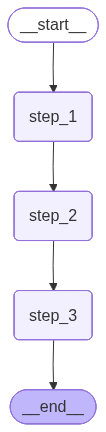

In [18]:
graph = graph_builder.compile()
graph

In [19]:
graph.invoke({"value_1": "apple"})

{'value_1': 'apple b', 'value_2': 10}

#**4. 노드와 엣지를 한번에 연결**

In [20]:
graph_builder = StateGraph(State).add_sequence([step_1, step_2, step_3])
graph_builder.add_edge(START, "step_1")

graph = graph_builder.compile()

graph.invoke({"value_1": "c"})

{'value_1': 'c b', 'value_2': 10}

#**5. 병렬로 연결**

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FbKsmXN%2FbtsQoa6BiQH%2FAAAAAAAAAAAAAAAAAAAAAPpgPBweh6r0kpol4tFqhOR7MdAaIfiH-Lj4HXxoNYBU%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3Det57M4W%252B1rxuWT1yQVw6r0BDHw4%253D'>

In [56]:
import operator
from typing import Annotated, Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    aggregate: Annotated[list, operator.add] # 업데이트 값이 뒤에 추가되도록 하는 operator.add 리듀서

In [57]:
def a(state: State):
    print(f'Adding "A" to {state["aggregate"]}')
    return {"aggregate": ["A"]}

def b(state: State):
    print(f'Adding "B" to {state["aggregate"]}')
    return {"aggregate": ["B"]}

def c(state: State):
    print(f'Adding "C" to {state["aggregate"]}')
    return {"aggregate": ["C"]}

def d(state: State):
    print(f'Adding "D" to {state["aggregate"]}')
    return {"aggregate": ["D"]}

In [58]:
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node(a)
graph_builder.add_node(b)
graph_builder.add_node(c)
graph_builder.add_node(d)

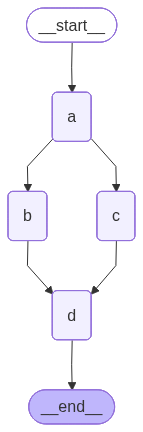

In [59]:
# 엣지 추가
graph_builder.add_edge(START, "a")
graph_builder.add_edge("a", "b") # a -> b
graph_builder.add_edge("a", "c") # a -> c
graph_builder.add_edge("b", "d") # b -> d
graph_builder.add_edge("c", "d") # c -> d
graph_builder.add_edge("d", END)
graph = graph_builder.compile()

graph

In [60]:
graph.invoke({"aggregate":[]})

Adding "A" to []
Adding "B" to ['A']
Adding "C" to ['A']
Adding "D" to ['A', 'B', 'C']


{'aggregate': ['A', 'B', 'C', 'D']}

#**6. 조건부 엣지 병렬 연결**

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FIHeX1%2FbtsQqoQbMcg%2FAAAAAAAAAAAAAAAAAAAAAI-WYn3hoGJZH0YGGZUAjDY2Xcsn6rtN7Qei9VUmGo2X%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3D2379LDy77wPIiHWUYKLbs2LPZvQ%253D'>

In [61]:
import operator
from typing import Annotated, Sequence
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    aggregate: Annotated[list, operator.add]
    which: str

In [62]:
def a(state: State):
    print(f'Adding "A" to {state["aggregate"]}')
    return {"aggregate": ["A"]}

def b(state: State):
    print(f'Adding "B" to {state["aggregate"]}')
    return {"aggregate": ["B"]}

def c(state: State):
    print(f'Adding "C" to {state["aggregate"]}')
    return {"aggregate": ["C"]}

def d(state: State):
    print(f'Adding "D" to {state["aggregate"]}')
    return {"aggregate": ["D"]}

def e(state: State):
    print(f'Adding "E" to {state["aggregate"]}')
    return {"aggregate": ["E"]}

In [63]:
graph_builder = StateGraph(State)
graph_builder.add_node(a)
graph_builder.add_node(b)
graph_builder.add_node(c)
graph_builder.add_node(d)
graph_builder.add_node(e)
graph_builder.add_edge(START, "a")

In [64]:
# bc 혹은 cd 로 라우트를 결정하는 함수
def route_bc_or_cd(state: State) -> Sequence[str]:
    if state["which"] == "cd":
        return ["c", "d"]
    return ["b", "c"]

intermediates = ["b", "c", "d"]
graph_builder.add_conditional_edges(
    "a",
    route_bc_or_cd,
    intermediates,
)

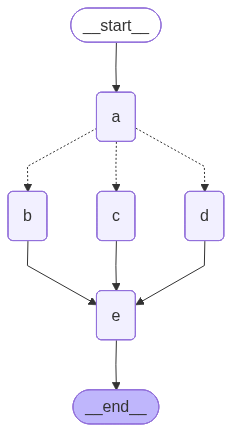

In [65]:
for node in intermediates:
    graph_builder.add_edge(node, "e")

graph_builder.add_edge("e", END)
graph = graph_builder.compile()
graph

In [66]:
graph.invoke({"aggregate": [], "which": "bc"})

Adding "A" to []
Adding "B" to ['A']
Adding "C" to ['A']
Adding "E" to ['A', 'B', 'C']


{'aggregate': ['A', 'B', 'C', 'E'], 'which': 'bc'}

In [67]:
graph.invoke({"aggregate": [], "which": "cd"})

Adding "A" to []
Adding "C" to ['A']
Adding "D" to ['A']
Adding "E" to ['A', 'C', 'D']


{'aggregate': ['A', 'C', 'D', 'E'], 'which': 'cd'}

#**7. 조건과 반복**

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FexNpm9%2FbtsQqoil95F%2FAAAAAAAAAAAAAAAAAAAAAIPncRoH-KNiTSy0fHLkuCYoGImVqZSYLqCJFGTP-wrG%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3D7XPcTIf3uYOEuTyJu5Y2j40yDEk%253D'>

In [68]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    aggregate: Annotated[list, operator.add]

In [69]:
def a(state: State):
    print(f'Node A 처리 중 현재 상태값 : {state["aggregate"]}')
    return {"aggregate": ["A"]}


def b(state: State):
    print(f'Node B 처리 중 현재 상태값 : {state["aggregate"]}')
    return {"aggregate": ["B"]}


graph_builder = StateGraph(State)
graph_builder.add_node(a)
graph_builder.add_node(b)

In [70]:
def route(state: State):
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END


graph_builder.add_edge(START, "a")
graph_builder.add_conditional_edges("a", route)
graph_builder.add_edge("b", "a")
graph = graph_builder.compile()

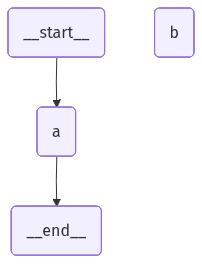

In [71]:
import requests, zlib, base64
from IPython.display import Image

# Mermaid 코드 추출
code = graph.get_graph().draw_mermaid()

# 압축·인코딩 후 Kroki 요청
encoded = base64.urlsafe_b64encode(zlib.compress(code.encode())).decode()
url = f"https://kroki.io/mermaid/png/{encoded}"
resp = requests.get(url)
display(Image(resp.content))

In [72]:
graph.invoke({"aggregate": []})

Node A 처리 중 현재 상태값 : []
Node B 처리 중 현재 상태값 : ['A']
Node A 처리 중 현재 상태값 : ['A', 'B']
Node B 처리 중 현재 상태값 : ['A', 'B', 'A']
Node A 처리 중 현재 상태값 : ['A', 'B', 'A', 'B']
Node B 처리 중 현재 상태값 : ['A', 'B', 'A', 'B', 'A']
Node A 처리 중 현재 상태값 : ['A', 'B', 'A', 'B', 'A', 'B']


{'aggregate': ['A', 'B', 'A', 'B', 'A', 'B', 'A']}

In [73]:
from langgraph.errors import GraphRecursionError
# GraphRecursionError 로 에러를 반환하는 방법
try:
    graph.invoke({"aggregate": []}, config={"recursion_limit": 4})
except GraphRecursionError: # 반복 종료 조건에 도달할 수 없는 경우
    print("Recursion Error")

Node A 처리 중 현재 상태값 : []
Node B 처리 중 현재 상태값 : ['A']
Node A 처리 중 현재 상태값 : ['A', 'B']
Node B 처리 중 현재 상태값 : ['A', 'B', 'A']
Recursion Error


#**8. 조건에 따른 반복 처리하기**

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fdrp6dk%2FbtsQoqO213W%2FAAAAAAAAAAAAAAAAAAAAACbLnCZ6cvYoZLtwmeOmdEtVH7cYJLals8GjOOMl45pz%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3DGhmniuUIB5pnuOxVfgFilZuWhWw%253D'>

In [74]:
import operator
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    aggregate: Annotated[list, operator.add]

In [75]:
def a(state: State):
    print(f'Node A 처리 중 현재 상태값 : {state["aggregate"]}')
    return {"aggregate": ["A"]}

def b(state: State):
    print(f'Node B 처리 중 현재 상태값 : {state["aggregate"]}')
    return {"aggregate": ["B"]}

def c(state: State):
    print(f'Node C 처리 중 현재 상태값 : {state["aggregate"]}')
    return {"aggregate": ["C"]}

def d(state: State):
    print(f'Node D 처리 중 현재 상태값 : {state["aggregate"]}')
    return {"aggregate": ["D"]}

graph_builder = StateGraph(State)
graph_builder.add_node(a)
graph_builder.add_node(b)
graph_builder.add_node(c)
graph_builder.add_node(d)

In [76]:
def route(state: State) -> Literal["b", END]:
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END


graph_builder.add_edge(START, "a")
graph_builder.add_conditional_edges("a", route)
graph_builder.add_edge("b", "c")
graph_builder.add_edge("b", "d")
graph_builder.add_edge(["c", "d"], "a")
graph = graph_builder.compile()

In [77]:
result = graph.invoke({"aggregate": []})

Node A 처리 중 현재 상태값 : []
Node B 처리 중 현재 상태값 : ['A']
Node C 처리 중 현재 상태값 : ['A', 'B']
Node D 처리 중 현재 상태값 : ['A', 'B']
Node A 처리 중 현재 상태값 : ['A', 'B', 'C', 'D']
Node B 처리 중 현재 상태값 : ['A', 'B', 'C', 'D', 'A']
Node C 처리 중 현재 상태값 : ['A', 'B', 'C', 'D', 'A', 'B']
Node D 처리 중 현재 상태값 : ['A', 'B', 'C', 'D', 'A', 'B']
Node A 처리 중 현재 상태값 : ['A', 'B', 'C', 'D', 'A', 'B', 'C', 'D']


#**9. 사용자 입력에 따른 반복 조건 설정**

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FW6D61%2FbtsQrJlLxdN%2FAAAAAAAAAAAAAAAAAAAAAP-0lx0tesNGzWsIggu1h7tH9Kp5d3qGQ_yTD39LBiDE%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3DDjcR%252BLev61HL%252FUKYyKPSteaeHHA%253D'>

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    human_messages: Annotated[list[HumanMessage], add_messages]
    ai_messages: Annotated[list[AIMessage], add_messages]
    retry_num : int

In [2]:
def chatbot(state:State):
    retry_num = state["retry_num"]
    user_input = input(f"(현재 {retry_num}번째 답변) 사용자 입력: ")
    ai_message = AIMessage(f"{retry_num}번째 답변중!")

    return {"human_messages": [HumanMessage(content=user_input)], "ai_messages": [ai_message]}

def retry(state: State):
    return {"retry_num" : state["retry_num"] + 1}

graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("retry", retry)

In [3]:
def route(state: State):
    if "반복" in state["human_messages"][-1].content:
        return "retry"
    else:
        return END


graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", route)
graph_builder.add_edge("retry", "chatbot")
graph = graph_builder.compile()

In [6]:
for chunk in graph.stream({"human_messages" : "반복", "retry_num": 0}, stream_mode="updates"):
    print(chunk)
    print()
    for node, value in chunk.items():
        if node:
            print(node)
        if "messages" in value:
            print(value['messages'].content)

{'chatbot': {'human_messages': [HumanMessage(content='반복', additional_kwargs={}, response_metadata={}, id='1b5311be-c17d-4a23-a169-c33fa3147092')], 'ai_messages': [AIMessage(content='0번째 답변중!', additional_kwargs={}, response_metadata={}, id='6f467a47-bea0-4168-914d-58c0189803f7', tool_calls=[], invalid_tool_calls=[])]}}

chatbot
{'retry': {'retry_num': 1}}

retry
(현재 1번째 답변) 사용자 입력: 응
{'chatbot': {'human_messages': [HumanMessage(content='응', additional_kwargs={}, response_metadata={}, id='1c2639d8-941c-4143-bbdc-4153905c56f9')], 'ai_messages': [AIMessage(content='1번째 답변중!', additional_kwargs={}, response_metadata={}, id='3a75c3de-88c3-471f-8e68-c5548ee9a4a9', tool_calls=[], invalid_tool_calls=[])]}}

chatbot


In [7]:
graph.invoke({"human_messages" : "반복", "retry_num": 0})

(현재 0번째 답변) 사용자 입력: 반복
(현재 1번째 답변) 사용자 입력: 뉴


{'human_messages': [HumanMessage(content='반복', additional_kwargs={}, response_metadata={}, id='cc8932a2-50cb-4c96-a9ee-0de055f66a7a'),
  HumanMessage(content='반복', additional_kwargs={}, response_metadata={}, id='9a86860e-cd6c-466b-bfa6-e8533f9de2a9'),
  HumanMessage(content='뉴', additional_kwargs={}, response_metadata={}, id='8ea8e43b-7243-4977-9217-d176c38a3ea1')],
 'ai_messages': [AIMessage(content='0번째 답변중!', additional_kwargs={}, response_metadata={}, id='5df6873f-d534-492b-8554-cd45dd4b19db', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='1번째 답변중!', additional_kwargs={}, response_metadata={}, id='215daf18-c559-4ca4-9c94-ff20877ddb9c', tool_calls=[], invalid_tool_calls=[])],
 'retry_num': 1}